# 01 - Fundamentals of Optimisation
---

### **Introduction**
Optimisation is a fundamentally different class of problem to those found in machine learning and many data scientist may never touch optimisation in their careers. Whereas ML is about trying to learn patterns in data and make predictions, optimisation problems are about maximimising or minimising some kind of process. These type of problems frequently occur in a variety of industries such as logistics, transport, business operations and manufactoring. Typically these types of problems also contain physical limitations and/or rules about what is and isn't allowed which are modelled as part of the optimisation process.

We can express a generic optimisation mathematically as follows:
$min f(x)$ subject to $x \in \mathcal{F}$
where:
- $f(x)$ is the objective
- $\mathcal{F}$ is the feasible set (i.e. the allowed values for x)

Generally when discussing optimisation we are essentially talking about the structure and form of $f(x)$ and $\mathcal{F}$ 

### **Continuous vs Discrete Optimisation**
Optimisation falls broadly into two categories:
- **Continuous**: Variables take real values $X \in \mathbb{R}$
- **Discrete**: Varibles take integer values $X \in \mathbb{Z}$

Generally continuous problems are easier to solve (polynomial-time) than discrete problems. Many discrete algorithms leverage this fact as a solution strategy by first relaxing the problem to turn it into a continuous one, solving it quickly and then apply techniques to find a discrete solution from the continuous solution. 

### **Objective Function**
The **objective function** represents what "best" means in the context of the problem. It takes the form of a mathematical expresion which assigns a numerical value to each possible solution which codifies what the optimisation algorithm tries to maximise or minimise. 

For example, suppose a factory produces two products:
- $x$: number of units of product A
- $y$: number of units of product B

If product A costs £5 per unit and product B costs £3 per unit, the total production cost is:
$Cost = 5x + 3y$

If we want to minimise cost, the optimisation problem begins:
$min\: 5x + 3y$

Suppose also that product A generates £8 profit per unit and product B generates £6 profit per unit. If our goal was to maximimise profit the objective would become:
$max\: 8x + 6y$

### **Constraints**
Constraints define what solutions are allowed. They represent physical limits, business rules, or logical requirements. Mathematically, constraints restrict the feasible set usually by using inequalities or by directly forcing a variable to take a certain value. 

Continuing on from our example above, suppose:
- Each unit of A requires 2 hours of labour
- Each unit of B requires 1 hour of labour
- Only 100 labour hours are available

We can express these constraints mathematically as:
- $2x + y \le 100$

This constraint ensures production does not exceed available labour.

In many real-world problems, negative values are not logical so we can add constraints to model this:
- $x \ge 0$
- $y \ge 0$

Similarly, often variables must be whole numbers:
- $x \in \mathbb{Z}$
- $y \in \mathbb{Z}$


### **Geomtric Interpretation**
Optimisation problems can be understood geometrically by plotting the objective and constraints graphically. 

The example below assumes the following problem setup:
- Objective: 
$$max\: y = 5x + 3$$
- Constraints: 
$$ x \le 5 $$
$$ y \ge -3x + 8$$

If we plot each of the lines, the enclosing region represents all the feasible values. Now the optimal value must occur at a vertex (see Fundamental Theorem of Linear Programming) so we could just loop through the vertices and compute the objective. However in this lower dimensional example we know that the optimal value must lie of the line 5x + 3 and since we are looking to maximise we know it must be the top-right vertex. Now this geometrical interpretation approach looses some of its power when moving to higher dimensions, but it can still be useful when thinking about optimisation problems conceptually. The optimal value exists on the vertex of a higher dimensional polyhedron.

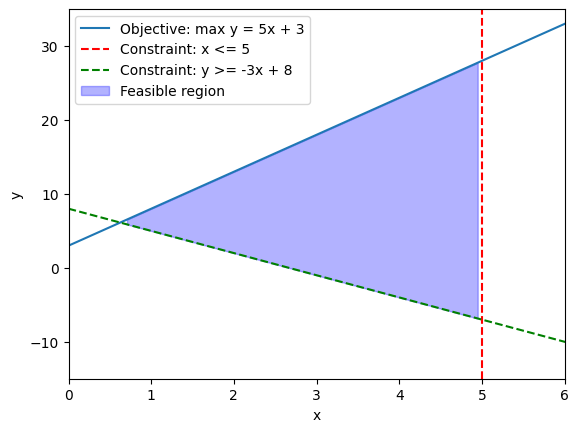

In [33]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 100)
objective = 5*x + 3
constraint = -3*x + 8


fig = plt.figure()
plt.plot(x, objective, label='Objective: max y = 5x + 3')
plt.axvline(x=5, linestyle='--', color='r', label='Constraint: x <= 5')
plt.plot(x, constraint, linestyle='--', color='g', label='Constraint: y >= -3x + 8')
plt.fill_between(x, objective, constraint, where=(constraint <= objective) & (x <= 5), alpha=0.3, color='blue', label='Feasible region')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.xlim(0, 6)
plt.ylim(-15, 35)
plt.show()

### **Fundamental Theorem of Linear Programming**